

`Práctica Nº 4 - Aprendizaje Profundo`



## **AUTOENCODERS PARA RECONSTRUCCIÓN DE IMÁGENES**

### *DataSet: Quick,Drawl - The Eiffel Tower*

### 00. Librerias

In [ ]:
import os
# Desactivar por completo el compilador que da error con la RTX Blackwell
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'
os.environ['XLA_FLAGS'] = '--xla_gpu_autotune_level=0'

import tensorflow as tf

# Configurar para que no reserve toda la memoria de golpe
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

I0000 00:00:1774943396.516251   13636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774943396.590025   13636 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774943397.648782   13636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1774943398.366300   13636 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binar

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K

### 01. DataSet

In [ ]:
!wget -O eiffel.npy https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/The%20Eiffel%20Tower.npy

--2026-03-31 09:49:58--  https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/The%20Eiffel%20Tower.npy
Resolving storage.googleapis.com (storage.googleapis.com)... 216.58.204.187, 192.178.25.123, 142.251.142.155, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|216.58.204.187|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105684064 (101M) [application/octet-stream]
Saving to: ‘eiffel.npy’

eiffel.npy          100%[===================>] 100.79M  15.1MB/s    in 7.3s    

utime(eiffel.npy): Operation not permitted
2026-03-31 09:50:06 (13.7 MB/s) - ‘eiffel.npy’ saved [105684064/105684064]



In [ ]:
eiffel = np.load("eiffel.npy")

In [ ]:
# Mostramos la forma original
print("Forma original del dataset:", eiffel.shape)

Forma original del dataset: (134801, 784)




> Exploración DataSet



In [ ]:
print("Dimensión de una muestra:", eiffel[0].shape)

Dimensión de una muestra: (784,)


In [ ]:
#reorganización
eiffel_reshaped = np.reshape(eiffel, (eiffel.shape[0], 28, 28))

print("Nueva forma:", eiffel_reshaped.shape)

Nueva forma: (134801, 28, 28)


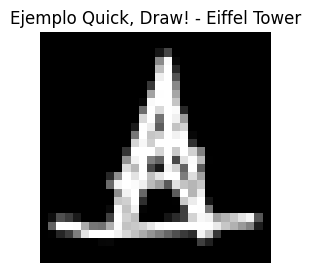

In [ ]:
#Visualizacion de imagen
plt.figure(figsize=(3, 3))
plt.imshow(eiffel_reshaped[0], cmap="gray")
plt.title("Ejemplo Quick, Draw! - Eiffel Tower")
plt.axis("off")
plt.show()



> Preprocesamiento



In [ ]:
x = eiffel_reshaped.astype("float32") / 255.0

In [ ]:
x = np.reshape(x, (x.shape[0], 28, 28, 1))

In [ ]:
print("Forma final para la red:", x.shape)
print("Valor mínimo:", x.min())
print("Valor máximo:", x.max())

Forma final para la red: (134801, 28, 28, 1)
Valor mínimo: 0.0
Valor máximo: 1.0


###02. División Train / Test

In [ ]:
max_samples = min(50000, x.shape[0])
x = x[:max_samples]

In [ ]:
# Mezclamos aleatoriamente
np.random.seed(42)
indices = np.random.permutation(len(x))
x = x[indices]

In [ ]:
# División 80% entrenamiento y 20% test
split = int(0.8 * len(x))
x_train = x[:split]
x_test = x[split:]

In [ ]:
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

x_train: (40000, 28, 28, 1)
x_test: (10000, 28, 28, 1)


###03. Visualización Muestra

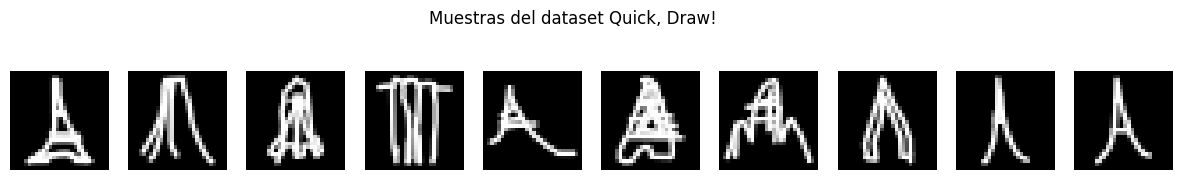

In [ ]:
n = 10
plt.figure(figsize=(15, 2))

for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Muestras del dataset Quick, Draw!", y=1.05)
plt.show()

###04. Autoencoder Básico

In [ ]:
input_img = layers.Input(shape=(28, 28, 1))



> ENCODER



In [ ]:
# Primera convolución
x_enc = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)

# Reducimos resolución
x_enc = layers.MaxPooling2D((2, 2), padding='same')(x_enc)

# Segunda convolución
x_enc = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x_enc)

# Segunda reducción
encoded = layers.MaxPooling2D((2, 2), padding='same')(x_enc)

W0000 00:00:1774943403.487511   13636 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1774943403.624619   13636 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5228 MB memory:  -> device: 0, name: NVIDIA RTX PRO 1000 Blackwell Generation Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
E0000 00:00:1774943403.792111   13714 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.0.140, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.
W0000 00:00:1774943403.796142   13714 subprocess_compilation.cc:241] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
W0000 00:00:1774943403.796166   13714 subproce



> DECODER



In [ ]:
#Reconstruir desde la representación comprimida
x_dec = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)

In [ ]:
x_dec = layers.UpSampling2D((2, 2))(x_dec)
x_dec = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x_dec)
x_dec = layers.UpSampling2D((2, 2))(x_dec)

In [ ]:
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x_dec)

In [ ]:
# Modelo completo
autoencoder = keras.Model(input_img, decoded)

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', jit_compile=False)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

###05. Entrenamiento del Autoencoder

In [ ]:
history_ae = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/20


W0000 00:00:1774943405.616725   13786 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774943405.618192   13791 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774943405.620643   13780 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774943405.621362   13788 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774943405.622846   13783 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774943405.624594   13779 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774943405.635324   13780 gpu_kernel_to_blob_pass.cc:190] Failed to co

  1/313 ━━━━━━━━━━━━━━━━━━━━ 30:53 6s/step - loss: 0.6945

W0000 00:00:1774943410.305867   13709 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774943410.367967   13709 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.1888 - val_loss: 0.1344
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1279 - val_loss: 0.1236
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1208 - val_loss: 0.1189
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1169 - val_loss: 0.1157
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.1141 - val_loss: 0.1131
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1119 - val_loss: 0.1112
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1101 - val_loss: 0.1096
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1087 - val_loss: 0.1085
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1075 - val_loss: 0.1072
Epoch 10/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1065 - val_loss: 0.1065
Epoch 11/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1057 - val_loss: 0.1059
Epoch 12/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - lo



> Graficas de perdida del autoencoder



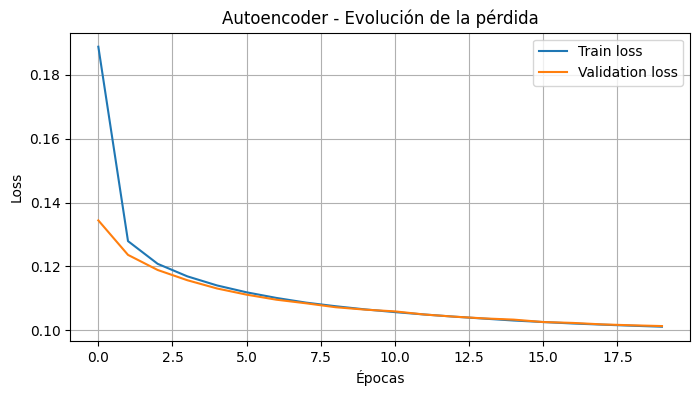

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_ae.history["loss"], label="Train loss")
plt.plot(history_ae.history["val_loss"], label="Validation loss")
plt.title("Autoencoder - Evolución de la pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



> Reconstrucción de imagenes



 95/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

W0000 00:00:1774943471.913012   13701 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


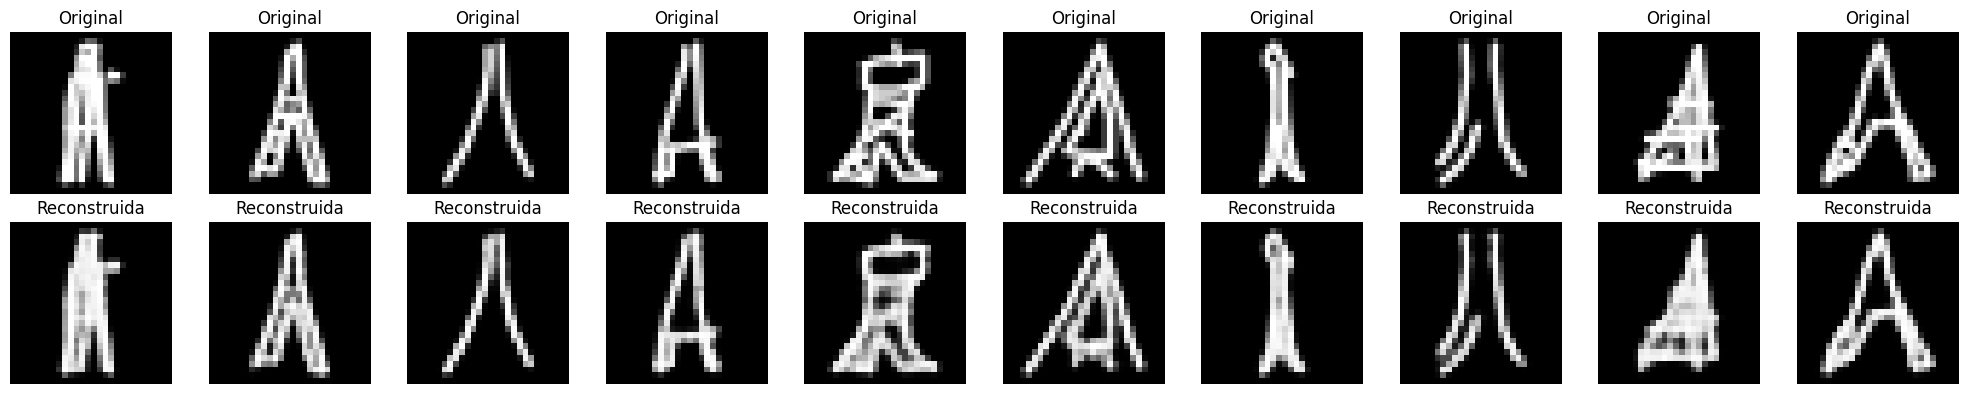

In [ ]:
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Imagen original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Imagen reconstruida
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstruida")
    plt.axis("off")

plt.tight_layout()
plt.show()



> Autoencoder para eliminar ruido



In [ ]:
noise_factor = 0.5

# Añadimos ruido gaussiano
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Limitamos valores al rango [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("x_train_noisy:", x_train_noisy.shape)
print("x_test_noisy:", x_test_noisy.shape)

x_train_noisy: (40000, 28, 28, 1)
x_test_noisy: (10000, 28, 28, 1)




> Visualización imagen con ruido



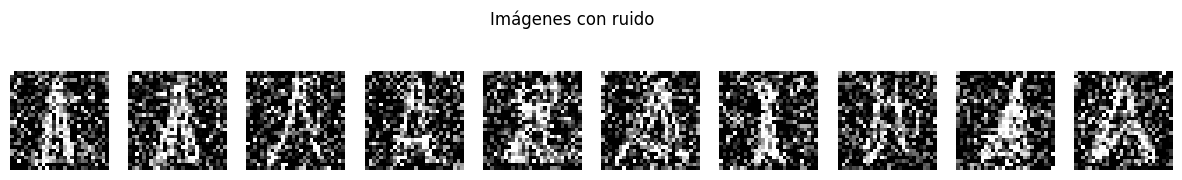

In [ ]:
n = 10
plt.figure(figsize=(15, 2))

for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Imágenes con ruido", y=1.05)
plt.show()

###06. Modelo para elimar ruido

In [ ]:
input_img_noise = layers.Input(shape=(28, 28, 1))



> ENCODER



In [ ]:
x_enc = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img_noise)
x_enc = layers.MaxPooling2D((2, 2), padding='same')(x_enc)
x_enc = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x_enc)
encoded_noise = layers.MaxPooling2D((2, 2), padding='same')(x_enc)



> DECODER



In [ ]:
x_dec = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded_noise)
x_dec = layers.UpSampling2D((2, 2))(x_dec)
x_dec = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x_dec)
x_dec = layers.UpSampling2D((2, 2))(x_dec)
decoded_noise = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x_dec)

In [ ]:
# Modelo completo
autoencoder_noise = keras.Model(input_img_noise, decoded_noise)

# Compilación
autoencoder_noise.compile(optimizer='adam', loss='binary_crossentropy', jit_compile=False)

# Resumen
autoencoder_noise.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

###07. Entrenamiento del autoencoder con ruido

In [ ]:
history_denoise = autoencoder_noise.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2457 - val_loss: 0.1871
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1786 - val_loss: 0.1730
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1689 - val_loss: 0.1661
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1637 - val_loss: 0.1622
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1602 - val_loss: 0.1592
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1573 - val_loss: 0.1565
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1553 - val_loss: 0.1550
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1535 - val_loss: 0.1534
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1521 - val_loss: 0.1520
Epoch 10/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1509 - val_loss: 0.1512
Epoch 11/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1498 - val_loss: 0.1497
Epoch 12/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10



> Resultado de eliminación de ruido


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


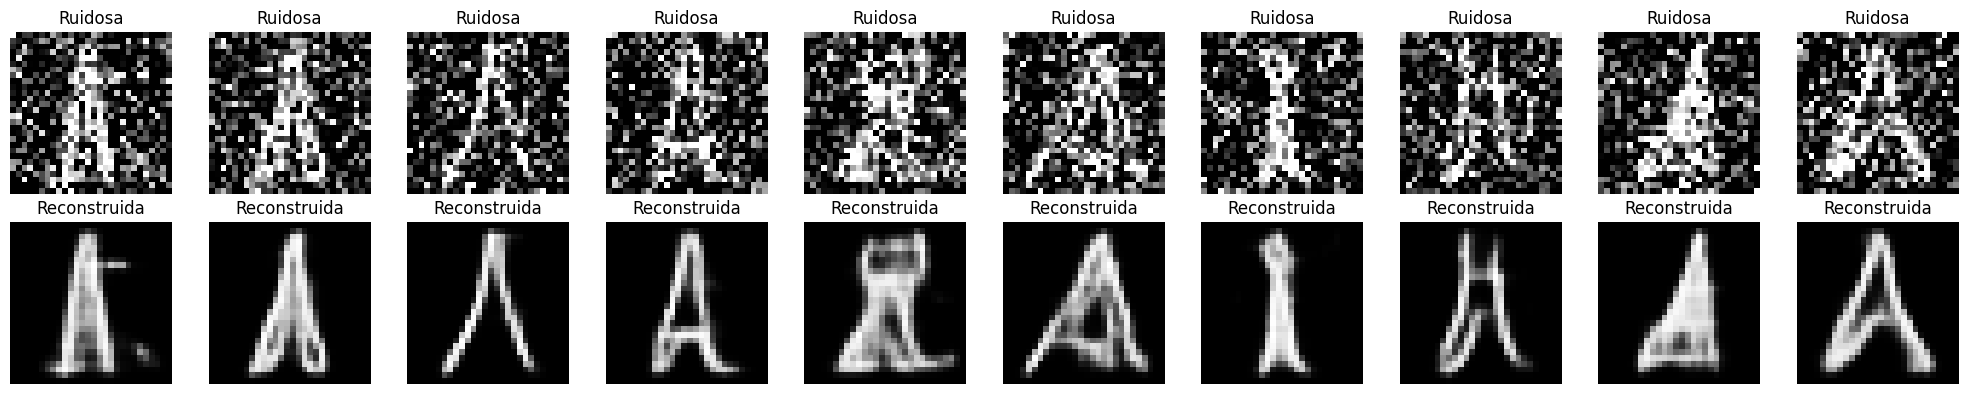

In [ ]:
decoded_denoised = autoencoder_noise.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Imagen ruidosa
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Ruidosa")
    plt.axis("off")

    # Imagen reconstruida / limpia
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_denoised[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstruida")
    plt.axis("off")

plt.tight_layout()
plt.show()

###08. Variational Autoencoder (VAE)

In [ ]:
class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs

        # Tamaño del batch
        batch = tf.shape(z_mean)[0]

        # Dimensión del espacio latente
        dim = tf.shape(z_mean)[1]

        # Ruido aleatorio de una normal estándar
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))

        # Reparametrización
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon



> Encoder del VAE



In [ ]:
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))

# Primera convolución
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)

# Segunda convolución
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)

# Aplanamos
x = layers.Flatten()(x)

# Capa densa intermedia
x = layers.Dense(16, activation="relu")(x)

# Media del espacio latente
z_mean = layers.Dense(latent_dim, name="z_mean")(x)

# Log-varianza del espacio latente
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Muestreo
z = Sampling()([z_mean, z_log_var])

# Modelo encoder
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)



> Decoder del VAE



In [ ]:
latent_inputs = keras.Input(shape=(latent_dim,))

# Expandimos desde el espacio latente
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)

# Reconvertimos a mapa de características
x = layers.Reshape((7, 7, 64))(x)

# Deconvolución / transposed convolution
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)

# Segunda deconvolución
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)

# Salida final
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

# Modelo decoder
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

###09. Clase Completa del VAE

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
       return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)

            # Reconstruimos con el decoder
            reconstruction = self.decoder(z)

            # Pérdida de reconstrucción
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            # Pérdida KL
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            # Pérdida total
            total_loss = reconstruction_loss + kl_loss

        # Calculamos gradientes
        grads = tape.gradient(total_loss, self.trainable_weights)

        # Actualizamos pesos
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Actualizamos métricas
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }



> Entrenamiento del VAE



In [ ]:
vae = VAE(encoder, decoder)

vae.compile(optimizer=keras.optimizers.Adam(), jit_compile=False)

history_vae = vae.fit(
    x_train,
    epochs=20,
    batch_size=128,
    validation_data=None,
    verbose=1
)

Epoch 1/20
  5/313 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - kl_loss: 0.0084 - loss: 540.6304 - reconstruction_loss: 540.6221

W0000 00:00:1774943530.713245   13706 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - kl_loss: 2.2649 - loss: 250.0269 - reconstruction_loss: 247.7619
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 3.6329 - loss: 216.5309 - reconstruction_loss: 212.8980
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 3.3892 - loss: 212.3949 - reconstruction_loss: 209.0055
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 3.1629 - loss: 210.2910 - reconstruction_loss: 207.1282
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 3.0852 - loss: 209.3247 - reconstruction_loss: 206.2394
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 3.0418 - loss: 208.8585 - reconstruction_loss: 205.8167
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - kl_loss: 3.0138 - loss: 208.4564 - reconstruction_loss: 205.4426 
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - kl_loss: 2.9852 - loss: 208.2420 - reconstruction_loss: 205.2567
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/ste



> Reconstrucción con el VAE



In [ ]:
import numpy as tf_numpy

# 1. Pasamos los datos a un tensor de TensorFlow
x_test_tensor = tf.convert_to_tensor(x_test, dtype=tf.float32)

# 2. Ejecutamos el modelo en modo "llamada directa" (esto evita el motor de predict/XLA)
# Lo forzamos en CPU para asegurar compatibilidad total con los pesos
with tf.device('/CPU:0'):
    # Movemos temporalmente los pesos a CPU para esta operación
    outputs = encoder(x_test_tensor, training=False)

    # Keras devuelve una lista [z_mean, z_log_var, z]
    z_mean_test = outputs[0].numpy()
    z_log_var_test = outputs[1].numpy()
    z_test = outputs[2].numpy()

print("Predicción completada con éxito.")

Predicción completada con éxito.


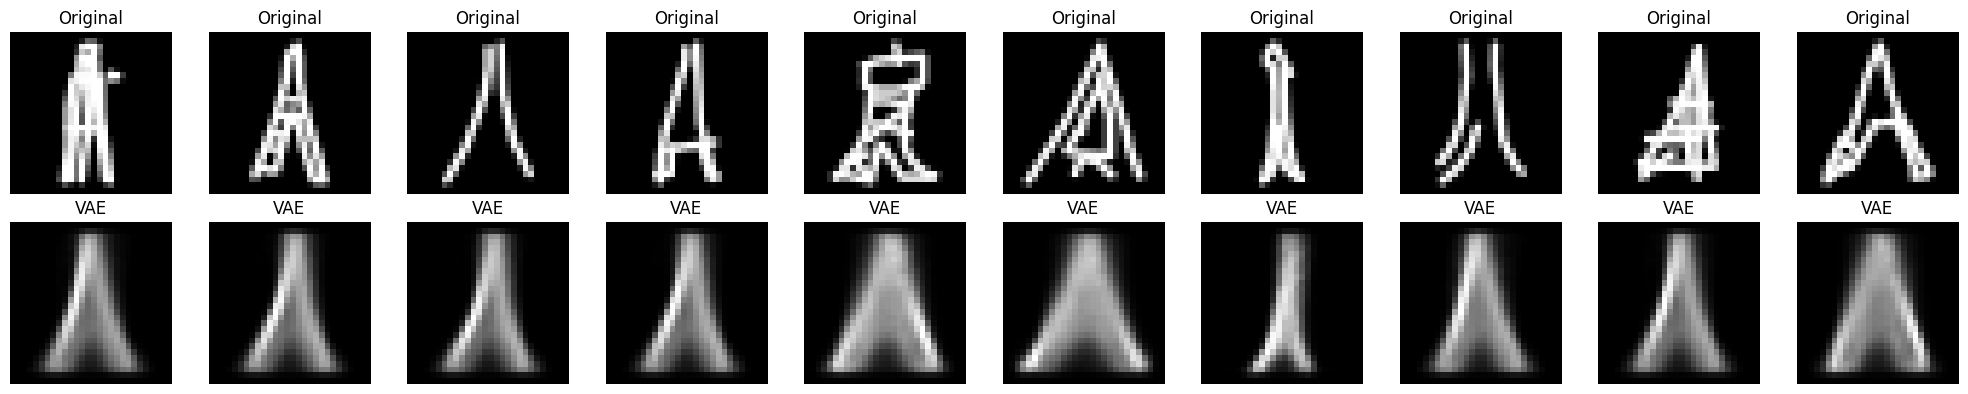

In [ ]:
# Sustituye la línea decoded_vae = decoder.predict(z_test) por esta:
import tensorflow as tf

# Convertimos z_test a tensor y llamamos al modelo directamente (modo Eager)
# Esto evita que se active XLA/Autotuner y el error de ptxas
z_test_tensor = tf.convert_to_tensor(z_test, dtype=tf.float32)
decoded_vae = decoder(z_test_tensor, training=False).numpy()

# El resto de tu código para graficar se mantiene igual
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstruida
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_vae[i].reshape(28, 28), cmap="gray")
    plt.title("VAE")
    plt.axis("off")

plt.tight_layout()
plt.show()

###10. Visualización del espacio latente

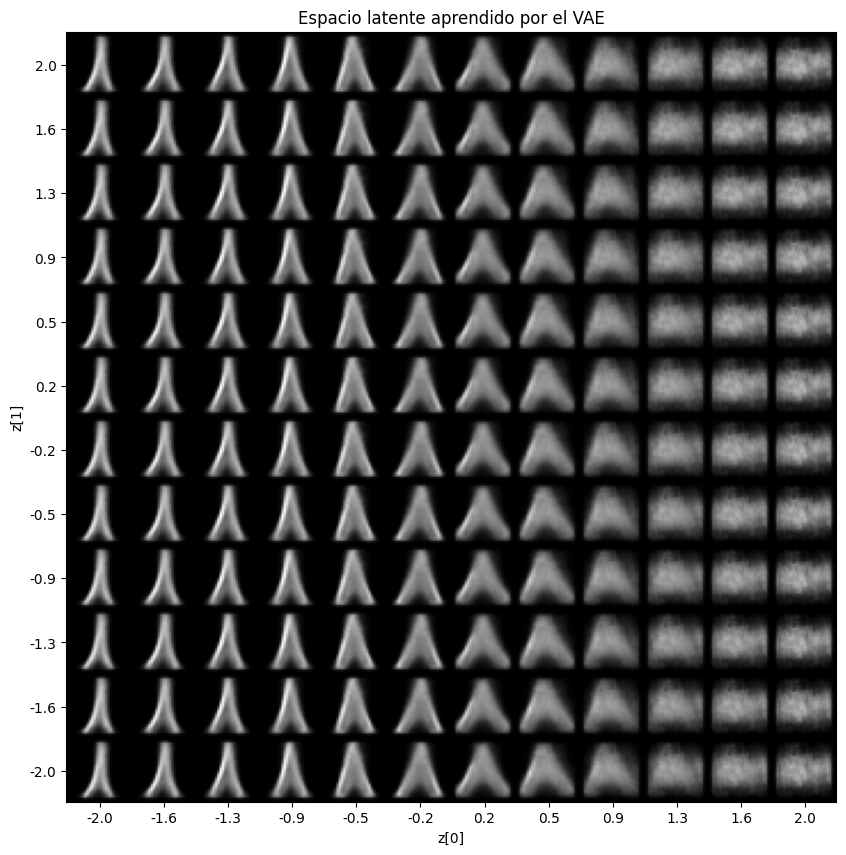

In [ ]:
def plot_latent_space(decoder, n=15, figsize=12):
    digit_size = 28
    scale = 2.0
    figure = np.zeros((digit_size * n, digit_size * n))

    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]], dtype=np.float32)

            # --- CAMBIO AQUÍ: Llamada directa en lugar de .predict() ---
            # Usamos training=False y convertimos a numpy al final
            x_decoded = decoder(z_sample, training=False).numpy()
            # ----------------------------------------------------------

            digit = x_decoded[0].reshape(digit_size, digit_size)

            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)

    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title("Espacio latente aprendido por el VAE")
    plt.imshow(figure, cmap="gray")
    plt.show()

# Ejecutar la función
plot_latent_space(decoder, n=12, figsize=10)